# Practice 04 — Final Report Challenge
**Context:** This is the capstone exercise. You need to build a complete, export-ready report figure that you could hand directly to your manager or the paid media team.

No hints this time — use everything from the course and previous practices.

---

## The brief

Build a **single multi-panel figure** that tells this story:

> *"Over Q1 2024, the card application funnel received strong traffic but lost most users at two key points: the start of the application and the document upload step. Paid channel has the lowest CVR. Email has the best. Here's the evidence."*

---

## Requirements

**Layout (use GridSpec):**
- Panel A (top, wide): Daily sessions trend with weekend shading and a 7-day rolling mean
- Panel B (bottom-left): Funnel drop-off horizontal bar chart with color coding
- Panel C (bottom-center): CVR by channel (bar chart, sorted)
- Panel D (bottom-right): OTP completion rate over time by channel (line chart)

**Quality requirements:**
- Figure size: 14x9 inches, dpi 150
- Panel labels: A, B, C, D in the top-left corner of each panel
- Consistent color palette across all panels (define it once, use it everywhere)
- Apply your `apply_report_style()` function from course notebook 07
- Figure title: "Card Acquisition Funnel — Q1 2024"
- Export as both PDF and PNG to `data/`

**Annotation requirements:**
- Annotate the biggest drop-off step in Panel B
- Add a target CVR line in Panel C (e.g., 3%)
- In Panel A, mark the start of February with a vertical line labeled "Feb"

---

## Tips
- Start by computing all your data before touching matplotlib
- Build each panel in a separate cell first, then combine
- Run `plt.rcdefaults()` if your styles get confused

In [5]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

In [6]:

# Step 1 — Compute all data first

funnel_steps  = ['visita_landing', 'inicio_solicitud', 'datos_personales', 'otp',
                  'datos_financieros', 'carga_documentos', 'evaluacion_crediticia',
                  'aprobacion', 'firma_digital', 'activacion_tarjeta']
funnel_labels = ['Visits', 'Start', 'Personal', 'OTP', 'Financial',
                 'Docs', 'Credit', 'Approved', 'Signed', 'Activated']

# Panel A — Daily sessions trend
daily = df.groupby('date').agg(sessions=('visita_landing', 'sum')).reset_index()
daily['roll7'] = daily['sessions'].rolling(7, min_periods=1).mean()

# Panel B — Funnel drop-off % at each step
totals    = df[funnel_steps].sum()
drop_pct  = [(totals[funnel_steps[i - 1]] - totals[funnel_steps[i]]) /
              totals[funnel_steps[i - 1]] * 100
             for i in range(1, len(funnel_steps))]
drop_labels = funnel_labels[1:]  # steps where drop is measured

# Panel C — CVR by channel (visit → activation), sorted ascending
channel_cvr = df.groupby('channel').apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).sort_values(ascending=True)

# Panel D — OTP rate over time by channel
otp_by_channel = df.groupby(['date', 'channel']).apply(
    lambda g: g['otp'].sum() / g['inicio_solicitud'].sum() * 100
).reset_index(name='otp_rate')


In [7]:

# Step 2 — Style function and color palette

PALETTE = {
    'organic': '#4361ee',
    'paid':    '#f72585',
    'email':   '#06d6a0',
    'social':  '#fb8500',
    'direct':  '#7209b7',
}
CHANNEL_LIST = list(PALETTE.keys())

FONT = 'Optima'

def apply_report_style(ax, title='', xlabel='', ylabel='',
                       title_size=13, label_size=11, tick_size=9):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=tick_size)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FONT)
    if title:
        ax.set_title(title, fontsize=title_size, fontweight='bold', pad=8,
                     fontfamily=FONT)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=label_size, fontfamily=FONT)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=label_size, fontfamily=FONT)


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_15503/862401139.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


Saved: data/q1_funnel_report.pdf and data/q1_funnel_report.png


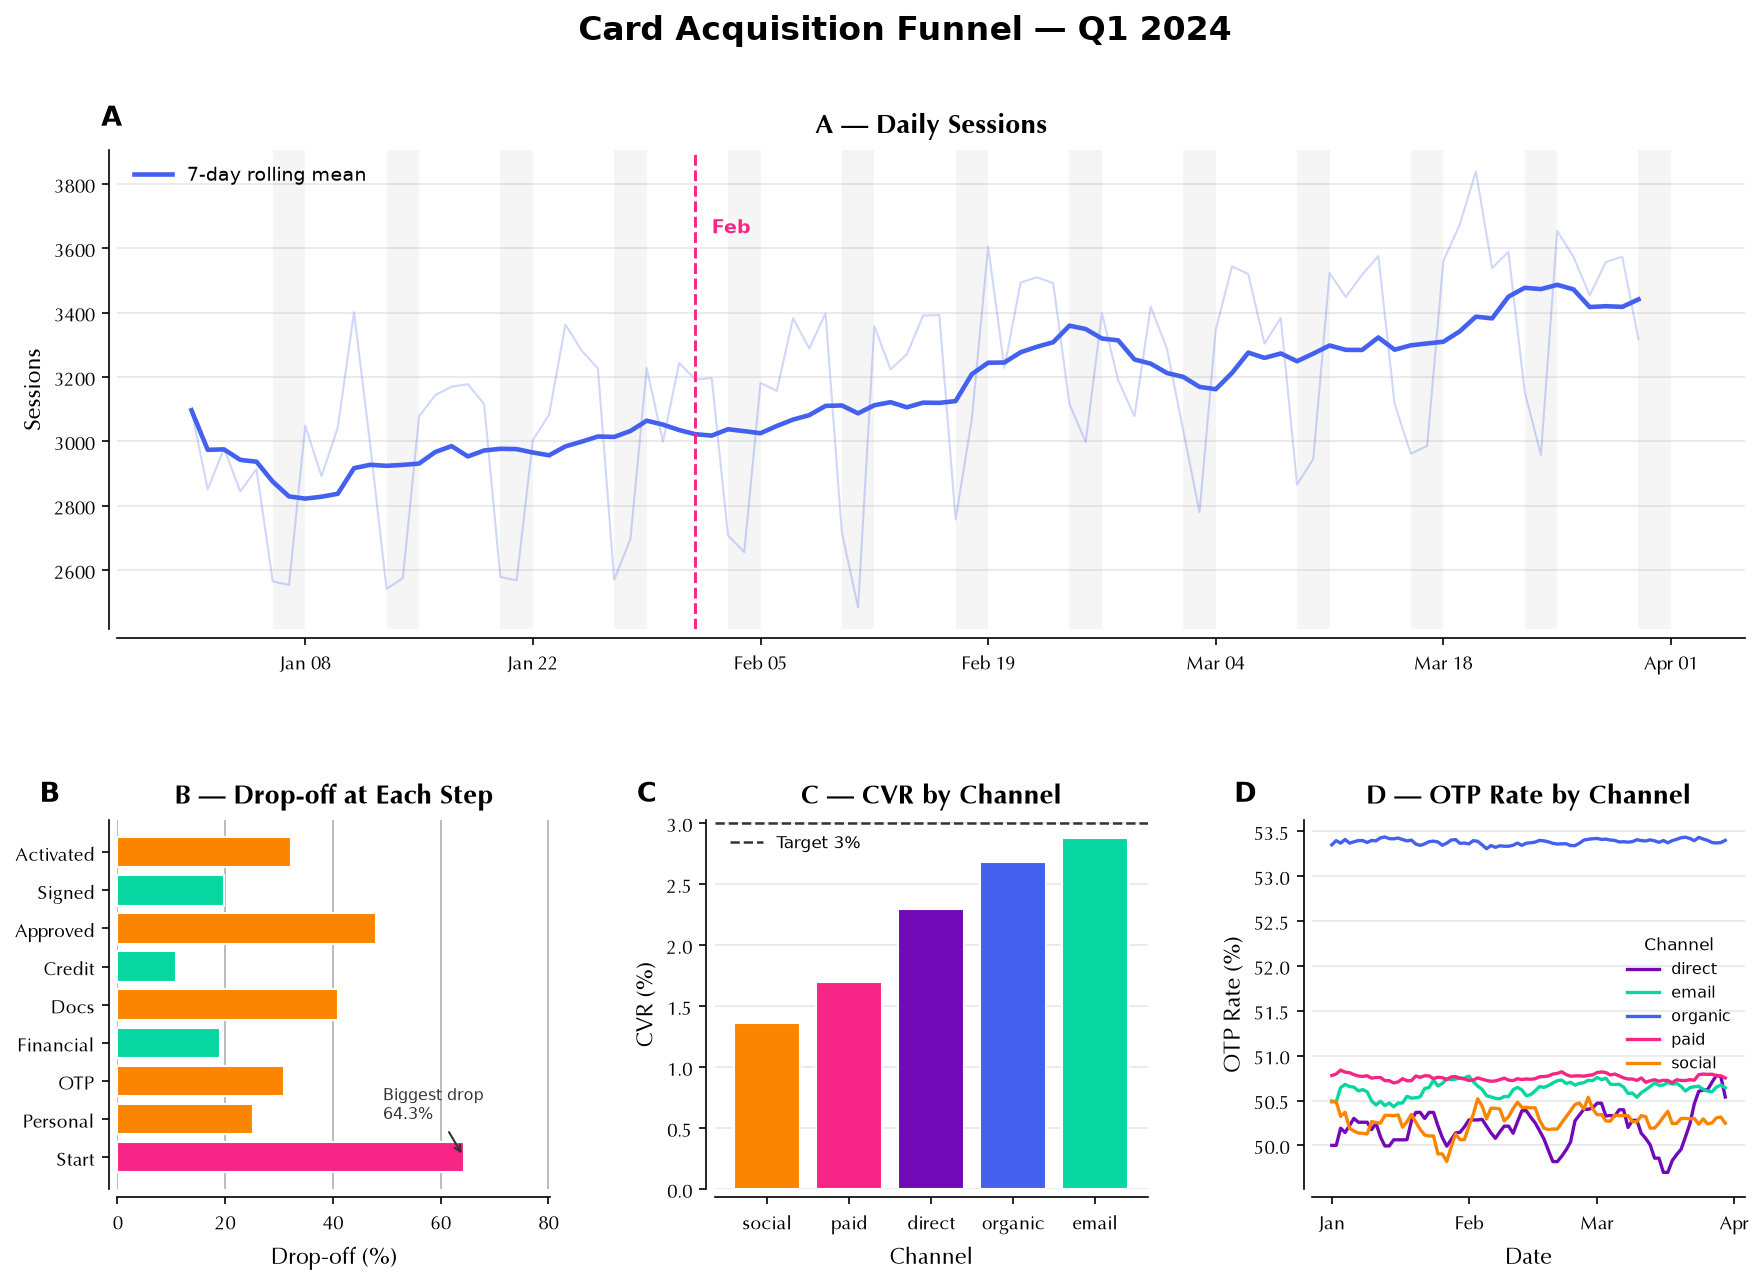

In [8]:

# Step 3 — Build the full figure

import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

fig = plt.figure(figsize=(14, 9), dpi=150)
fig.suptitle('Card Acquisition Funnel — Q1 2024', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.3, 1],
                       hspace=0.45, wspace=0.38)

ax_a = fig.add_subplot(gs[0, :])      # Panel A — wide top
ax_b = fig.add_subplot(gs[1, 0])      # Panel B — bottom left
ax_c = fig.add_subplot(gs[1, 1])      # Panel C — bottom center
ax_d = fig.add_subplot(gs[1, 2])      # Panel D — bottom right

# ── Panel A: Daily sessions with weekend shading, 7-day rolling mean ──────────
for date in daily['date']:
    if date.weekday() == 5:
        ax_a.axvspan(date, date + pd.Timedelta(days=2),
                     color='gray', alpha=0.08, linewidth=0)

ax_a.plot(daily['date'], daily['sessions'],
          color='#4361ee', alpha=0.25, linewidth=1)
ax_a.plot(daily['date'], daily['roll7'],
          color='#4361ee', linewidth=2.2, label='7-day rolling mean')

feb_start = pd.Timestamp('2024-02-01')
ax_a.axvline(feb_start, color='#f72585', linewidth=1.4, linestyle='--')
ax_a.text(feb_start + pd.Timedelta(days=1),
          daily['sessions'].max() * 0.95, 'Feb',
          color='#f72585', fontsize=9, fontweight='bold')

ax_a.legend(frameon=False, fontsize=9)
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_a.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=30, ha='right')
apply_report_style(ax_a, title='A — Daily Sessions', ylabel='Sessions')
ax_a.text(-0.01, 1.05, 'A', transform=ax_a.transAxes,
          fontsize=13, fontweight='bold')

# ── Panel B: Funnel drop-off horizontal bar ───────────────────────────────────
drop_colors = ['#f72585' if p > 50 else '#fb8500' if p > 25 else '#06d6a0'
               for p in drop_pct]
bars = ax_b.barh(drop_labels, drop_pct, color=drop_colors, edgecolor='white')

# Annotate the biggest drop-off
max_idx = drop_pct.index(max(drop_pct))
ax_b.annotate(f'Biggest drop\n{drop_pct[max_idx]:.1f}%',
              xy=(drop_pct[max_idx], max_idx),
              xytext=(drop_pct[max_idx] - 15, max_idx + 1),
              fontsize=7.5, color='#333',
              arrowprops=dict(arrowstyle='->', color='#333', lw=1))

ax_b.set_xlim(0, max(drop_pct) * 1.25)
apply_report_style(ax_b, title='B — Drop-off at Each Step', xlabel='Drop-off (%)')
ax_b.grid(axis='x')
ax_b.grid(axis='y', visible=False)
ax_b.text(-0.18, 1.05, 'B', transform=ax_b.transAxes,
          fontsize=13, fontweight='bold')

# ── Panel C: CVR by channel (sorted), target line ─────────────────────────────
bar_colors = [PALETTE.get(ch, '#aaa') for ch in channel_cvr.index]
ax_c.bar(channel_cvr.index, channel_cvr.values, color=bar_colors, edgecolor='white')
ax_c.axhline(3.0, color='#333', linestyle='--', linewidth=1.2, label='Target 3%')
ax_c.legend(frameon=False, fontsize=8)
apply_report_style(ax_c, title='C — CVR by Channel', ylabel='CVR (%)', xlabel='Channel')
ax_c.text(-0.18, 1.05, 'C', transform=ax_c.transAxes,
          fontsize=13, fontweight='bold')

# ── Panel D: OTP rate over time by channel ─────────────────────────────────────
for ch in otp_by_channel['channel'].unique():
    sub = otp_by_channel[otp_by_channel['channel'] == ch].sort_values('date')
    color = PALETTE.get(ch, '#aaa')
    ax_d.plot(sub['date'], sub['otp_rate'].rolling(7, min_periods=1).mean(),
              color=color, linewidth=1.6, label=ch)

ax_d.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_d.xaxis.set_major_locator(mdates.MonthLocator())
ax_d.legend(frameon=False, fontsize=7.5, title='Channel', title_fontsize=8)
apply_report_style(ax_d, title='D — OTP Rate by Channel', ylabel='OTP Rate (%)', xlabel='Date')
ax_d.text(-0.18, 1.05, 'D', transform=ax_d.transAxes,
          fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Export
fig.savefig('data/q1_funnel_report.pdf', bbox_inches='tight')
fig.savefig('data/q1_funnel_report.png', bbox_inches='tight', dpi=150)
print("Saved: data/q1_funnel_report.pdf and data/q1_funnel_report.png")

plt.show()
